In [1]:
import math
import numpy as np
import time
import torchvision
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch import nn, Tensor
from sklearn.datasets import make_moons
from sklearn.datasets import make_swiss_roll
from tqdm import tqdm

# flow_matching
from flow_matching.path import AffineProbPath, CondOTProbPath
from flow_matching.path.scheduler import (
    CondOTScheduler, PolynomialConvexScheduler, LinearVPScheduler, CosineScheduler
)
from flow_matching.solver import ODESolver 
from flow_matching.utils import ModelWrapper 

# visualization
import matplotlib.pyplot as plt
from matplotlib import cm


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: cuda


### Dataset

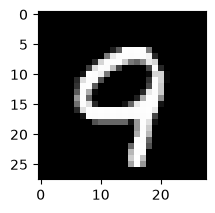

x_shape: torch.Size([128, 1, 28, 28])
min: 0.0 max: 1.0
mean: 0.1300688534975052, var: 0.09521302580833435


In [3]:
BATCH_SIZE = 128

data = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data',
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ]),
    download=True),
    batch_size=BATCH_SIZE,
    shuffle=True)

x, y = next(iter(data))     # Shape: (batch_size, 1, 28, 28)
x_sample = torch.permute(x[0], (1, 2, 0))

ax = plt.subplot(211)
ax.imshow(x_sample, cmap="gray")
plt.show()

print(f"x_shape: {x.shape}")
print(f"min: {torch.min(x_sample)} max: {torch.max(x_sample)}")
print(f"mean: {torch.mean(x)}, var: {torch.var(x)}")

In [4]:
print(x.shape)
print(x.view(x.shape[0], -1).shape)

print(torch.randn_like(x.view(x.shape[0], -1)).shape)

torch.Size([128, 1, 28, 28])
torch.Size([128, 784])
torch.Size([128, 784])


### Model Creation

In [5]:
image_size = 28
embed_dim=256
hidden_dim=embed_dim*3
num_heads=8
num_layers=6
patch_size=7
num_patches=16
num_channels=1
num_classes=10
dropout=0.2

In [6]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Inputs:
        x - Tensor representing the image of shape [B, C, H, W]
        patch_size - Number of pixels per dimension of the patches (integer)
        flatten_channels - If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, C, H, W = x.shape # [B, C, H, W], MNIST [B, 1, 28, 28]
    x = x.reshape(B, C, H // patch_size, patch_size, W // patch_size, patch_size) # [B, C, H', p_H, W', p_W], MNIST [B, 1, 4, 7, 4, 7]
    x = x.permute(0, 2, 4, 1, 3, 5)  # [B, H', W', C, p_H, p_W], MNIST [B, 4, 4, 1, 7, 7]
    x = x.flatten(1, 2)  # [B, H'*W', C, p_H, p_W], MNIST [B, 16, 1, 7, 7]
    if flatten_channels:
        x = x.flatten(2, 4)  # [B, H'*W', C*p_H*p_W], MNIST [B, 16, 49]
    return x

In [7]:
x.shape
x[:4].shape

torch.Size([4, 1, 28, 28])

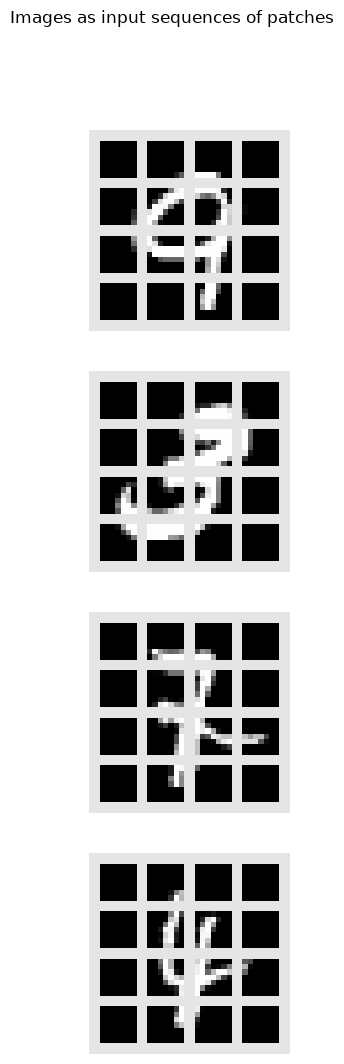

In [8]:
# Visualize the image patches
img_patches = img_to_patch(x[:4], patch_size=patch_size, flatten_channels=False)

fig, ax = plt.subplots(x[:4].shape[0], 1, figsize=(14, 12))
fig.suptitle("Images as input sequences of patches")
for i in range(x[:4].shape[0]):
    img_grid = torchvision.utils.make_grid(img_patches[i], nrow=int(image_size/patch_size), normalize=True, pad_value=0.9)
    img_grid = img_grid.permute(1, 2, 0)
    ax[i].imshow(img_grid)
    ax[i].axis("off")
plt.show()
plt.close()

#### Unpatchify test

In [9]:
def unpatchify(x: torch.Tensor, out_channels=1, patch_size=4) -> torch.Tensor:
    """
    Rearrange patch tokens back into a spatial feature map.

    Args:
        x: ``(N, T, patch_size**2 * C)``

    Returns:
        ``(N, C, H, W)``
    """
    c = out_channels
    p = patch_size
    h = w = int(x.shape[1] ** 0.5)
    assert h * w == x.shape[1]

    x = x.reshape(x.shape[0], h, w, p, p, c)
    x = torch.einsum("nhwpqc->nchpwq", x)
    return x.reshape(x.shape[0], c, h * p, h * p)

In [10]:
img_patches = img_to_patch(x[:4], patch_size=patch_size, flatten_channels=False)

print(f"x[:4].shape: {x[:4].shape}")
print(f"img_patches shape: {img_patches.shape}")    # (B, num_patches, num_channels, patch_size, patch_size)
print(f"num_patches: {num_patches}, patch_size: {patch_size}, num_channels: {num_channels}")

x[:4].shape: torch.Size([4, 1, 28, 28])
img_patches shape: torch.Size([4, 16, 1, 7, 7])
num_patches: 16, patch_size: 7, num_channels: 1


In [11]:
img_patches_flatten = img_patches.flatten(2, 4)  # [B, H'*W', C*p_H*p_W], MNIST [B, 16, 49]
print(f"img_patches_flatten.shape: {img_patches_flatten.shape}")

img_patches_flatten.shape: torch.Size([4, 16, 49])


img_reconstructed.shape: torch.Size([4, 1, 28, 28])


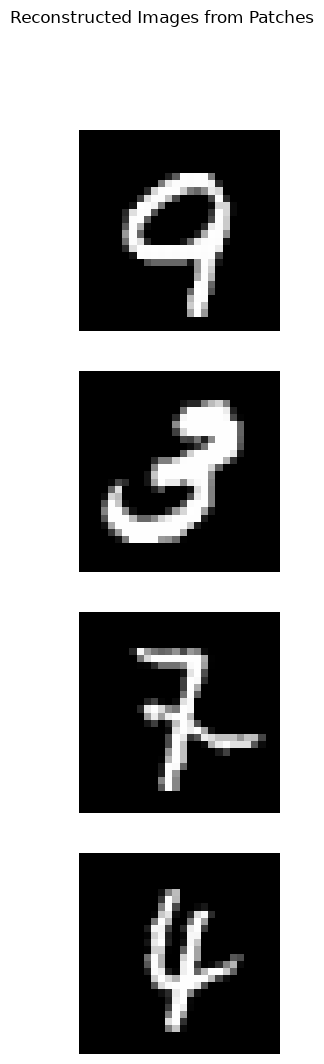

In [12]:
img_reconstructed = unpatchify(img_patches, out_channels=num_channels, patch_size=patch_size)
print(f"img_reconstructed.shape: {img_reconstructed.shape}")

# Visualize the reconstructed images
fig, ax = plt.subplots(img_reconstructed.shape[0], 1, figsize=(14, 12))
fig.suptitle("Reconstructed Images from Patches")
for i in range(img_reconstructed.shape[0]):
    img_grid = torchvision.utils.make_grid(img_reconstructed[i], nrow=1, normalize=True, pad_value=0.9)
    img_grid = img_grid.permute(1, 2, 0)
    ax[i].imshow(img_grid)
    ax[i].axis("off")
plt.show()

##### Positional Embeddings

In [13]:
# ---------------------------------------------------------------------------
# Positional embedding utilities
# ---------------------------------------------------------------------------

def get_1d_sincos_pos_embed_from_grid(embed_dim: int, pos: np.ndarray) -> np.ndarray:
    """
    Compute 1-D sinusoidal positional embeddings.

    Args:
        embed_dim: Output dimension for each position (must be even).
        pos:       Positions to encode, arbitrary shape – will be flattened.

    Returns:
        Embedding array of shape ``(M, embed_dim)``.
    """
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.0
    omega = 1.0 / 10000**omega                          # (D/2,)

    pos = pos.reshape(-1)                                # (M,)
    out = np.einsum("m,d->md", pos, omega)               # (M, D/2)

    return np.concatenate([np.sin(out), np.cos(out)], axis=1)  # (M, D)


def get_2d_sincos_pos_embed_from_grid(embed_dim: int, grid: np.ndarray) -> np.ndarray:
    assert embed_dim % 2 == 0
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])  # (H*W, D/2)
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])  # (H*W, D/2)
    return np.concatenate([emb_h, emb_w], axis=1)                       # (H*W, D)


def get_2d_sincos_pos_embed(
    embed_dim: int,
    grid_size: int,
    cls_token: bool = False,
    extra_tokens: int = 0,
) -> np.ndarray:
    """
    Generate 2-D sinusoidal positional embeddings on a square grid.

    Args:
        embed_dim:    Embedding dimension.
        grid_size:    Height (= width) of the grid.
        cls_token:    If *True*, prepend ``extra_tokens`` zero rows.
        extra_tokens: Number of extra token slots to prepend.

    Returns:
        Array of shape ``[grid_size*grid_size, embed_dim]`` (or with
        ``extra_tokens`` additional leading rows when requested).
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)           # w first
    grid = np.stack(grid, axis=0).reshape(2, 1, grid_size, grid_size)

    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token and extra_tokens > 0:
        pos_embed = np.concatenate(
            [np.zeros([extra_tokens, embed_dim]), pos_embed], axis=0
        )
    return pos_embed

In [14]:
num_patches = 400
pos_embedding_shape = 2000

# Fixed sinusoidal position embedding
grid_size = int(num_patches ** 0.5)
assert grid_size * grid_size == num_patches, "num_patches must be a perfect square."

# get_2d_sincos_pos_embed ultimately requires embed_dim % 4 == 0
embed_dim = pos_embedding_shape
if embed_dim % 4 != 0:
    embed_dim += (4 - embed_dim % 4)
    print(f"Adjusted pos_embedding_shape to {embed_dim} (must be divisible by 4).")

pos_embed = get_2d_sincos_pos_embed(embed_dim, grid_size)


In [15]:
print(f"pos_embed shape: {pos_embed.shape}")

pos_embed shape: (400, 2000)


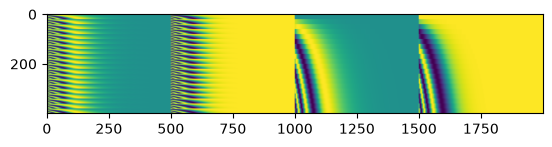

In [16]:
plt.imshow(pos_embed, cmap="viridis")

##### Model

In [19]:
class SinusoidalPosEmb(nn.Module):
    # TODO: Investigate
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

# ---------------------------------------------------------------------------
# Model Creation
# ---------------------------------------------------------------------------
# Model from: https://mashaan14.github.io/YouTube-channel/vision_transformers/2023_11_29_VisionTransformer_MNIST.html
class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        """
        Inputs:
            embed_dim - Dimensionality of input and attention feature vectors
            hidden_dim - Dimensionality of hidden layer in feed-forward network
                         (usually 2-4x larger than embed_dim)
            num_heads - Number of heads to use in the Multi-Head Attention block
            dropout - Amount of dropout to apply in the feed-forward network
        """
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        inp_x = self.layer_norm_1(x)
        x = x + self.attn(inp_x, inp_x, inp_x)[0]
        x = x + self.linear(self.layer_norm_2(x))
        return x

# ---------------------------------------------------------------------------
# Final projection layer
# ---------------------------------------------------------------------------
class FinalLayer(nn.Module):
    """Final projection: LayerNorm → SiLU → Linear  →  patch-level predictions."""

    def __init__(self, hidden_size: int, patch_size: int, out_channels: int):
        super().__init__()
        self.norm_final = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.linear = nn.Linear(hidden_size, patch_size * patch_size * out_channels, bias=True)
        # self.silu = nn.SiLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # return self.linear(self.silu(self.norm_final(x)))
        return self.linear(self.norm_final(x))


# ---------------------------------------------------------------------------
# Vision Transformer
# ---------------------------------------------------------------------------
class VisionTransformer(nn.Module):
    def __init__(
        self,
        embed_dim,
        hidden_dim,
        num_channels,
        num_heads,
        num_layers,
        num_classes,
        patch_size,
        num_patches,
        dropout=0.0,
        time_dim=256,
    ):
        """
        Inputs:
            embed_dim - Dimensionality of the input feature vectors to the Transformer
            hidden_dim - Dimensionality of the hidden layer in the feed-forward networks
                         within the Transformer
            num_channels - Number of channels of the input (3 for RGB or 1 for grayscale)
            num_heads - Number of heads to use in the Multi-Head Attention block
            num_layers - Number of layers to use in the Transformer
            num_classes - Number of classes to predict
            patch_size - Number of pixels that the patches have per dimension
            num_patches - Maximum number of patches an image can have
            dropout - Amount of dropout to apply in the feed-forward network and
                      on the input encoding
        """
        super().__init__()

        self.patch_size = patch_size

        # Layers/Networks
        self.input_layer = nn.Linear(num_channels * (patch_size**2), embed_dim)
        self.transformer = nn.Sequential(
            *(AttentionBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers))
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, num_classes))
        self.dropout = nn.Dropout(dropout)

        # # Parameters/Embeddings
        # self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        # self.pos_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

        self.pos_embedding = nn.Parameter(
            torch.zeros(1, num_patches, embed_dim), requires_grad=False
        )

        # --- Diffusion params ---
        self.time_dim = time_dim    # Redundant?
        self.embed_dim = embed_dim
        self.num_patches = num_patches

            # Fixed sinusoidal position embedding
        pos_embed = get_2d_sincos_pos_embed(
            embed_dim, int(num_patches ** 0.5), cls_token=False, extra_tokens=0)
        self.pos_embedding.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))


        # -- Diffusion step encoder
        # Time embeddings
        diffusion_step_encoder = nn.Sequential(
            SinusoidalPosEmb(dim=embed_dim),
            # nn.Linear(self.time_dim, self.time_dim*4),
            # nn.Mish(),
            # nn.Linear(self.time_dim*4, self.time_dim),
        )
        self.diffusion_step_encoder = diffusion_step_encoder

        # -- Diffusion
        self.out_channels = num_channels

        # decoder head
        self.ln_f = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        # Final layer
        self.final_layer = FinalLayer(hidden_size=embed_dim, patch_size=patch_size, 
                                      out_channels=num_channels)


    # ----- helpers -----------------------------------------------------------
    def unpatchify(self, x: torch.Tensor) -> torch.Tensor:
        """
        Rearrange patch tokens back into a spatial feature map.

        Args:
            x: ``(N, T, patch_size**2 * C)``

        Returns:
            ``(N, C, H, W)``
        """
        c = self.out_channels
        p = self.patch_size
        h = w = int(x.shape[1] ** 0.5)
        assert h * w == x.shape[1]

        x = x.reshape(x.shape[0], h, w, p, p, c)
        x = torch.einsum("nhwpqc->nchpwq", x)
        return x.reshape(x.shape[0], c, h * p, h * p)

    # ----- forward -----------------------------------------------------------    
    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        # -- Time Embeddings
        # Get timestep embeddings
        timesteps = t
        if not torch.is_tensor(timesteps):
            # TODO: this requires sync between CPU and GPU. So try to pass timesteps as tensors if you can
            timesteps = torch.tensor([timesteps], dtype=torch.long, device=x.device)
        elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
            timesteps = timesteps[None].to(x.device)
        # broadcast to batch dimension in a way that's compatible with ONNX/Core ML
        timesteps = timesteps.expand(x.shape[0])
        t_emb = self.diffusion_step_encoder(timesteps)


        # -- Transformer passthrough
        # Preprocess input
        # Input shape: torch.Size([B, C, H, W])
        x = img_to_patch(x, self.patch_size)        # x.shape ---> batch, num_patches, (patch_size**2)
        B, T, _ = x.shape
        x = self.input_layer(x)                     # x.shape ---> batch, num_patches, embed_dim

        # Add time positional encoding
        # NOTE: Position embedding was critical.
        x = x + t_emb[:, None, :]                    # x.shape ---> batch, num_patches, embed_dim
        x = x + self.pos_embedding[:, : T]      # x.shape ---> batch, num_patches+1, embed_dim

        # Pass through the transformer
        x = self.dropout(x)
        x = x.transpose(0, 1)                       # x.shape ---> num_patches+1, batch, embed_dim
        x = self.transformer(x)                     # x.shape ---> num_patches+1, batch, embed_dim

        # TODO: Better upscaling?
        # Post transformer processing
        # Output shape: torch.Size([B, C, H, W])
        # [T, B, E] -> [B, T, E]
        x = x.transpose(0, 1)

        # Pass to final layer for reconstruction
        x = self.final_layer(x)                     # x.shape ---> batch, num_patches, (patch_size**2 * out_channels)
        return self.unpatchify(x)

        # # tokens -> spatial grid
        # B, T, E = x.shape
        # n = int(T ** 0.5)
        # if n * n != T:
        #     raise ValueError(f"Number of tokens ({T}) is not a perfect square.")

        # x = self.ln_f(x)
        # x = x.reshape(B, n, n, E).permute(0, 3, 1, 2)  # [B, E, n, n]

        # # map to image resolution
        # x = torch.nn.functional.interpolate(
        #     x,
        #     size=(image_size, image_size),
        #     mode="bilinear",
        #     align_corners=False,
        # )

        # # match input channel count
        # out_channels = self.input_layer.in_features // (self.patch_size ** 2)
        # if out_channels == 1:
        #     x = x.mean(dim=1, keepdim=True)
        # else:
        #     x = x[:, :out_channels]

        # return x


In [20]:
x_test = torch.randn((BATCH_SIZE, 1, 28, 28)).to(device)
model = VisionTransformer(
    embed_dim=64,
    hidden_dim=128,
    num_channels=1,
    num_heads=4,
    num_layers=6,
    num_classes=10,
    patch_size=4,
    num_patches=49,
    dropout=0.1,
).to(device)
# out = model(x_test)
out = model(x=x_test, t=0.5)

print("Output shape:", out.shape)

Output shape: torch.Size([128, 1, 28, 28])


### Training

In [21]:
# -- Params
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
EPOCHS = 50

# -- Dataset 
train_dataloader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data',
    transform=torchvision.transforms.ToTensor(),
    download=True),
    batch_size=BATCH_SIZE,
    shuffle=True)

# -- Define paths
# affine path with alpha_t = t, sigma_t = 1 - t
path = AffineProbPath(scheduler=CondOTScheduler())

# -- Model
model = VisionTransformer(
    embed_dim=64,
    hidden_dim=128,
    num_channels=1,
    num_heads=4,
    num_layers=6,
    num_classes=10,
    patch_size=4,
    num_patches=49,
    dropout=0.1,
).to(device)
model.train()

# -- Training
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()
losses = []

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    epoch_loss = 0.0
    pbar = tqdm(train_dataloader)

    for i, (images, labels) in enumerate(pbar):
        # Randomize time t ~ Uniform(0, 1)
        t = torch.rand(images.size(0)).to(device)

        # Sample x1 and x0 (x0 is gaussian)
        x1 = images.to(device)
        _ = labels.to(device)

        x0 = torch.randn_like(x1).to(device)

        # Sample path
        sample = path.sample(t=t, x_0=x0, x_1=x1)

        # Compute loss and optimize
        # loss = torch.pow(model(t=t, x=sample.x_t) - sample.dx_t, 2).mean()
        loss = torch.pow(model(t=t, x=sample.x_t) - sample.x_1, 2).mean()

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        # Update epoch loss and progress bar
        epoch_loss += loss.item()
        pbar.set_description(f"Loss: {epoch_loss / (i + 1):.4f}")
    
    losses.append(epoch_loss / len(train_dataloader))

Epoch 1/50


Loss: 0.0688: 100%|██████████| 235/235 [00:04<00:00, 47.78it/s]


Epoch 2/50


Loss: 0.0471: 100%|██████████| 235/235 [00:04<00:00, 49.31it/s]


Epoch 3/50


...

Loss: 0.0312: 100%|██████████| 235/235 [00:05<00:00, 42.76it/s]


Epoch 49/50


Loss: 0.0311: 100%|██████████| 235/235 [00:05<00:00, 42.78it/s]


Epoch 50/50


Loss: 0.0309: 100%|██████████| 235/235 [00:05<00:00, 42.76it/s]


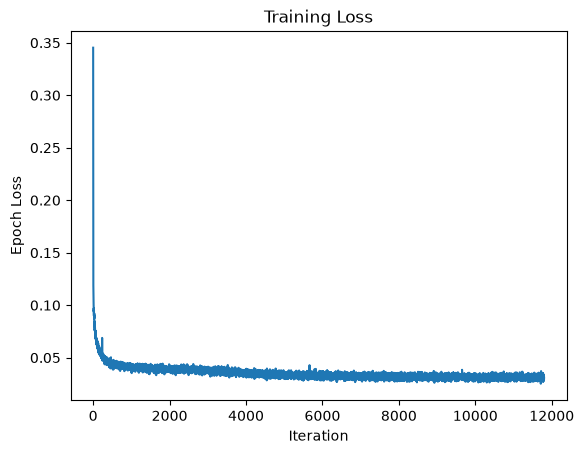

In [22]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Epoch Loss")
plt.title("Training Loss")
plt.show()

### Sampling

In [27]:
# Convert from denoiser to velocity prediction
class VelocityModel(ModelWrapper):
    def __init__(self, denoiser: nn.Module, path: AffineProbPath):
        super().__init__(denoiser)
        self.path = path

    def forward(self, t: Tensor, x: Tensor, **extras) -> Tensor:
        x_1_predictions = super().forward(t=t, x=x, **extras)
        return self.path.target_to_velocity(x_1=x_1_predictions, x_t=x, t=t)

In [34]:
num_steps = 10
batch_size = 256
T = torch.linspace(0, 1, num_steps) 

velocity_model = VelocityModel(denoiser=model, path=path)
solver = ODESolver(velocity_model=velocity_model)

x_init = torch.randn((BATCH_SIZE, 1, 28, 28), dtype=torch.float32, device=device)
x_1 = solver.sample(
    time_grid=T.to(device),
    x_init=x_init,
    method='midpoint',
    step_size=1.0 / num_steps,
    return_intermediates=True,
)

print("Sampled x_1 shape:", x_1.shape)
x_1 = x_1.permute(0, 1, 3, 4, 2)
print("Permuted x_1 shape:", x_1.shape)

x_1 = x_1.cpu().numpy()
print("Numpy x_1 shape:", x_1.shape)

Sampled x_1 shape: torch.Size([10, 256, 1, 28, 28])
Permuted x_1 shape: torch.Size([10, 256, 28, 28, 1])
Numpy x_1 shape: (10, 256, 28, 28, 1)


Random index for visualization: 135


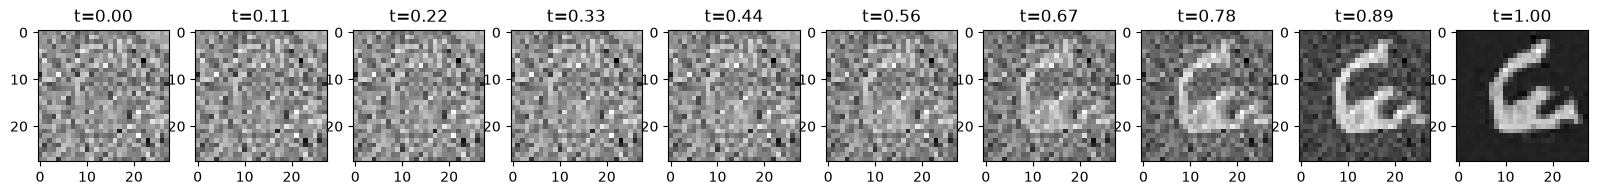

In [41]:
# -- Visualization of samples
import numpy as np
x_min, x_max = x_1.min(), x_1.max()
_, axs = plt.subplots(1, num_steps, figsize=(20, 3.2))


rand_idx = np.random.randint(0, x_1.shape[1], (1,)).item()
print(f"Random index for visualization: {rand_idx}")
for i in range(num_steps):
    # axs[i].scatter(x_1[i, :, 0], x_1[i, :, 1], s=5, alpha=0.5)
    axs[i].imshow(x_1[i, rand_idx, :, :], cmap="gray")
    axs[i].set_title(f"t={T[i].item():.2f}")
    # axs[i].set_xlim(x_min, x_max)
    # axs[i].set_ylim(x_min, x_max)
    axs[i].set_aspect('equal')

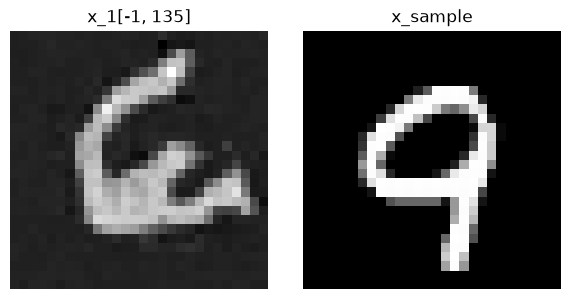

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

# Generated sample at final step
axs[0].imshow(x_1[-1, rand_idx, :, :], cmap="gray")
axs[0].set_title(f"x_1[-1, {rand_idx}]")
axs[0].axis("off")

# Original MNIST sample
axs[1].imshow(x_sample.squeeze().cpu().numpy(), cmap="gray")
axs[1].set_title("x_sample")
axs[1].axis("off")

plt.tight_layout()
plt.show()
